# 📊 Démonstration - Plateforme ML Pairs Trading

Ce notebook démontre l'utilisation du pipeline complet de pairs trading.

**Modules utilisés :**
- `DataFetcher` : Téléchargement des données
- `PairsSelector` : Sélection de paires cointégrées
- `Backtester` : Simulation de stratégie
- `RiskManager` : Gestion du risque
- `TradingPipeline` : Orchestration complète

## 1. Imports et Configuration

In [1]:
# Imports
import sys
sys.path.append('..') 
from backend.app.pipeline import TradingPipeline
from backend.app.core.data_fetcher import DataFetcher
from backend.app.core.data_source import YahooFinanceSource
from backend.app.core.pairs_selector import PairsSelector
from backend.app.core.backtester import Backtester
from backend.app.core.risk_manager import RiskManager
from backend.app.core.strategies import ZScoreReversionStrategy
import matplotlib.pyplot as plt
import pandas as pd

# Configuration du style des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(" Imports réussis")

 Imports réussis


## 2. Configuration du Pipeline

In [2]:
# Configuration personnalisée
config = {
    'capital_initial': 10000.0,
    'seuil_entree': 2.0,
    'seuil_sortie': 0.5,
    'correlation_threshold': 0.7,
    'pvalue_threshold': 0.05,
    'max_position_size': 0.1,
    'stop_loss_pct': 0.02,
    'max_leverage': 1.0
}

# Construction des composants injectés dans le pipeline
fetcher = DataFetcher(source=YahooFinanceSource())
selector = PairsSelector(
    correlation_threshold=config['correlation_threshold'],
    pvalue_threshold=config['pvalue_threshold']
)
strategie = ZScoreReversionStrategy(
    seuil_entree=config['seuil_entree'],
    seuil_sortie=config['seuil_sortie']
)
backtester = Backtester(strategy=strategie, capital_initial=config['capital_initial'])
risk_manager = RiskManager(
    max_position_size=config['max_position_size'],
    stop_loss_pct=config['stop_loss_pct'],
    max_leverage=config['max_leverage']
)

# Initialisation du pipeline
pipeline = TradingPipeline(fetcher, selector, backtester, risk_manager)

print(" Pipeline initialisé")
print(f"Capital initial : {config['capital_initial']:.2f} €")
print(f"Seuils : Entrée = {config['seuil_entree']}, Sortie = {config['seuil_sortie']}")

 Pipeline initialisé
Capital initial : 10000.00 €
Seuils : Entrée = 2.0, Sortie = 0.5


## 3. Exécution d'un Backtest Simple

In [3]:
# Paramètres du backtest
ticker_a = 'AAPL'
ticker_b = 'MSFT'
start_date = '2023-01-01'
end_date = '2024-01-01'

print(f" Exécution du backtest sur {ticker_a}-{ticker_b}...\n")

# Exécution du backtest complet
resultats = pipeline.executer_backtest(
    ticker_a=ticker_a,
    ticker_b=ticker_b,
    start_date=start_date,
    end_date=end_date,
    appliquer_risk_management=True
)

print(" Backtest terminé")

 Exécution du backtest sur AAPL-MSFT...

 Backtest terminé


## 4. Rapport de Performance

In [4]:
# Affichage du rapport complet
pipeline.generer_rapport(resultats)

RAPPORT DE BACKTEST - PAIRS TRADING

 PAIRE ANALYSÉE
  Ticker A : AAPL
  Ticker B : MSFT
  Période : 2023-01-03 → 2023-12-29
  Nombre de jours : 250

 VALIDATION STATISTIQUE
  Cointégration : OUI
  P-value : 0.0111
  Ratio de couverture : 0.7364

 PERFORMANCE
  Rendement total : 20.74 %
  Sharpe Ratio : 2.02
  Maximum Drawdown : -5.17 %
  Win Rate : 59.42 %
  Nombre de trades : 19

  GESTION DU RISQUE
  Perte maximale : 0.00 € (0.00 %)
  Volatilité quotidienne : 0.6527 %
  VaR 95% : -0.5076 %
  Ratio gain/perte : 1.41

  Stop-loss global déclenché : NON
  Stop-loss position déclenché : NON

CAPITAL
  Capital initial : 10000.00 €
  Capital final : 12073.81 €
  Profit/Perte : 2073.81 €



## 5. Visualisations

### 5.1 Évolution des Prix

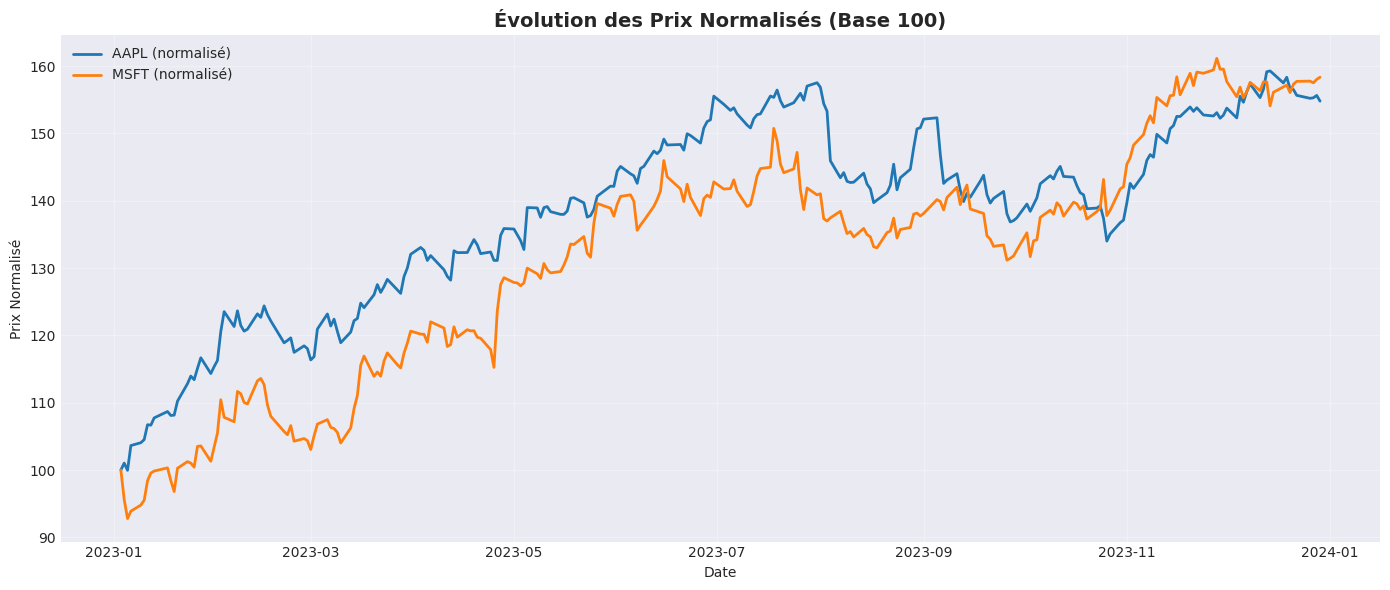

In [5]:
# Graphique des prix normalisés
pair_data = resultats['donnees_paire']

prix_a_norm = pair_data[f'Close_{ticker_a}'] / pair_data[f'Close_{ticker_a}'].iloc[0] * 100
prix_b_norm = pair_data[f'Close_{ticker_b}'] / pair_data[f'Close_{ticker_b}'].iloc[0] * 100

plt.figure(figsize=(14, 6))
plt.plot(prix_a_norm.index, prix_a_norm, label=f'{ticker_a} (normalisé)', linewidth=2)
plt.plot(prix_b_norm.index, prix_b_norm, label=f'{ticker_b} (normalisé)', linewidth=2)
plt.title('Évolution des Prix Normalisés (Base 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix Normalisé')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Spread et Z-Score

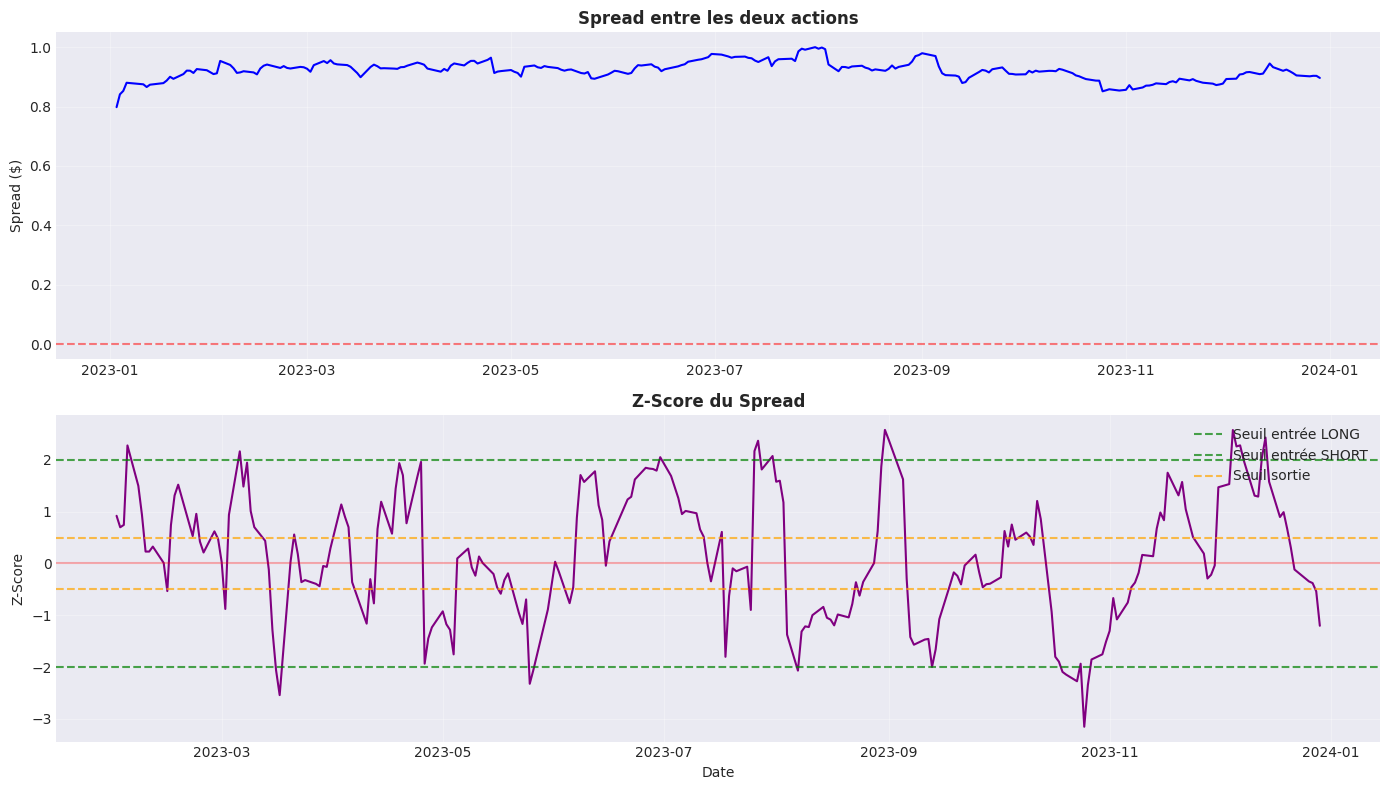

In [6]:
# Graphique du spread et z-score
spread = resultats['spread']
zscore = resultats['zscore']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Spread
axes[0].plot(spread.index, spread, color='blue', linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Spread entre les deux actions', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Spread ($)')
axes[0].grid(True, alpha=0.3)

# Z-Score avec seuils
axes[1].plot(zscore.index, zscore, color='purple', linewidth=1.5)
axes[1].axhline(y=config['seuil_entree'], color='green', linestyle='--', label='Seuil entrée LONG', alpha=0.7)
axes[1].axhline(y=-config['seuil_entree'], color='green', linestyle='--', label='Seuil entrée SHORT', alpha=0.7)
axes[1].axhline(y=config['seuil_sortie'], color='orange', linestyle='--', label='Seuil sortie', alpha=0.7)
axes[1].axhline(y=-config['seuil_sortie'], color='orange', linestyle='--', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='-', alpha=0.3)
axes[1].set_title('Z-Score du Spread', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Z-Score')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Equity Curve (Courbe de Capital)

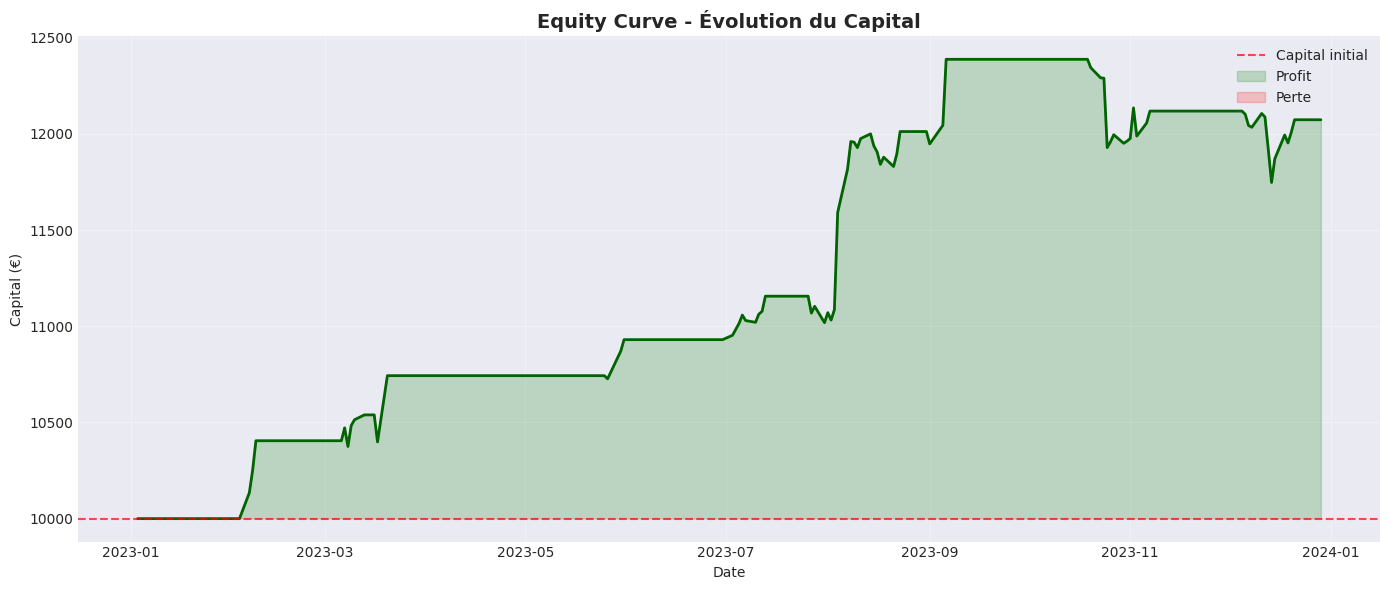


 Capital initial : 10000.00 €
Capital final : 12073.81 €
Profit/Perte : 2073.81 € (20.74%)


In [7]:
# Graphique de la courbe de capital
df_trades = resultats['df_trades']

plt.figure(figsize=(14, 6))
plt.plot(df_trades.index, df_trades['capital'], linewidth=2, color='darkgreen')
plt.axhline(y=config['capital_initial'], color='red', linestyle='--', label='Capital initial', alpha=0.7)
plt.fill_between(df_trades.index, config['capital_initial'], df_trades['capital'], 
                 where=(df_trades['capital'] >= config['capital_initial']), 
                 color='green', alpha=0.2, label='Profit')
plt.fill_between(df_trades.index, config['capital_initial'], df_trades['capital'], 
                 where=(df_trades['capital'] < config['capital_initial']), 
                 color='red', alpha=0.2, label='Perte')

plt.title('Equity Curve - Évolution du Capital', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Capital (€)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Statistiques finales
capital_final = df_trades['capital'].iloc[-1]
profit_total = capital_final - config['capital_initial']

print(f"\n Capital initial : {config['capital_initial']:.2f} €")
print(f"Capital final : {capital_final:.2f} €")
print(f"Profit/Perte : {profit_total:.2f} € ({(profit_total/config['capital_initial']*100):.2f}%)")

### 5.4 Distribution des Rendements Quotidiens

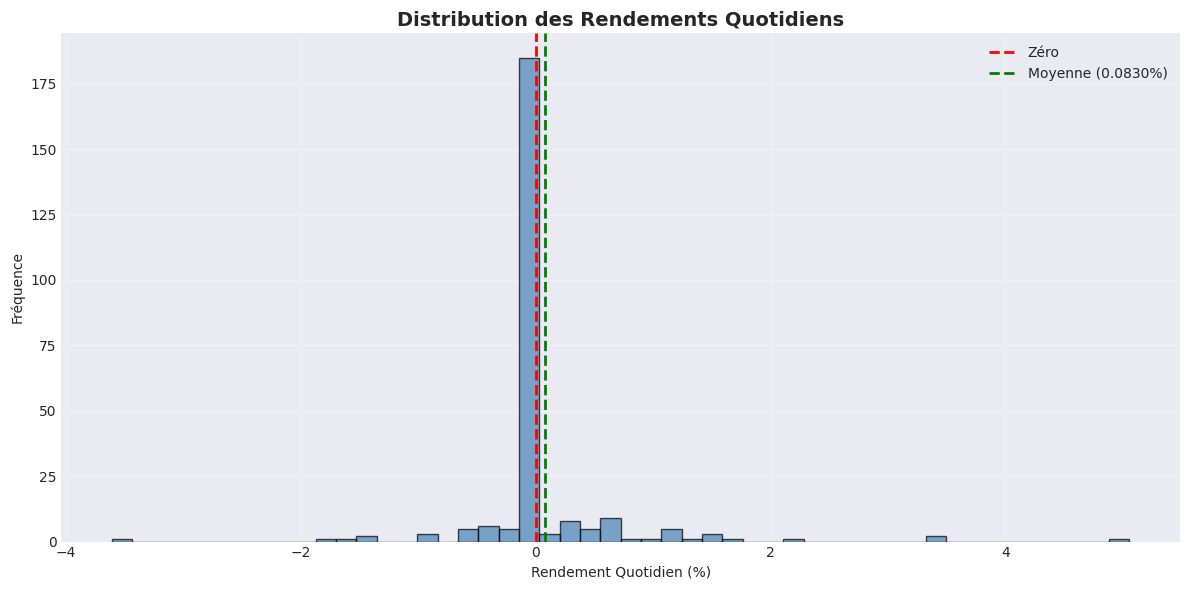

In [8]:
# Histogramme des rendements quotidiens
rendements = df_trades['pnl_quotidien'] / config['capital_initial'] * 100

plt.figure(figsize=(12, 6))
plt.hist(rendements, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zéro')
plt.axvline(x=rendements.mean(), color='green', linestyle='--', linewidth=2, label=f'Moyenne ({rendements.mean():.4f}%)')
plt.title('Distribution des Rendements Quotidiens', fontsize=14, fontweight='bold')
plt.xlabel('Rendement Quotidien (%)')
plt.ylabel('Fréquence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparaison de Plusieurs Paires

Analysons et comparons plusieurs paires pour identifier la meilleure opportunité.

In [9]:
# Liste des paires à analyser
paires_a_tester = [
    ('AAPL', 'MSFT'),
    ('JPM', 'BAC'),
    ('PEP', 'KO'),
    ('XOM', 'CVX')
]

print("Analyse de plusieurs paires...\n")

# Analyse de chaque paire
comparaison = []

for ticker_a, ticker_b in paires_a_tester:
    print(f"Analyse de {ticker_a}-{ticker_b}...")
    
    try:
        res = pipeline.executer_backtest(
            ticker_a=ticker_a,
            ticker_b=ticker_b,
            start_date='2023-01-01',
            end_date='2024-01-01',
            appliquer_risk_management=True
        )
        
        comparaison.append({
            'Paire': f"{ticker_a}-{ticker_b}",
            'Cointégrée': 'OUI' if res['est_cointegree'] else 'NON',
            'P-value': res['p_valeur'],
            'Rendement (%)': res['metriques']['rendement_total'],
            'Sharpe Ratio': res['metriques']['sharpe_ratio'],
            'Max Drawdown (%)': res['metriques']['max_drawdown'],
            'Win Rate (%)': res['metriques']['win_rate'],
            'Nb Trades': res['metriques']['nombre_trades']
        })
        
    except Exception as e:
        print(f"Erreur : {e}")
        continue

print("\nAnalyse terminée\n")

Analyse de plusieurs paires...

Analyse de AAPL-MSFT...
Analyse de JPM-BAC...
Analyse de PEP-KO...
Analyse de XOM-CVX...

Analyse terminée



In [10]:
# Affichage du tableau comparatif
df_comparaison = pd.DataFrame(comparaison)
print("TABLEAU COMPARATIF DES PAIRES\n")
print(df_comparaison.to_string(index=False))

# Identifier la meilleure paire
meilleure_paire = df_comparaison.loc[df_comparaison['Sharpe Ratio'].idxmax()]
print(f"\nMeilleure paire (Sharpe Ratio) : {meilleure_paire['Paire']}")
print(f"   Sharpe : {meilleure_paire['Sharpe Ratio']:.2f}")
print(f"   Rendement : {meilleure_paire['Rendement (%)']:.2f}%")

TABLEAU COMPARATIF DES PAIRES

    Paire Cointégrée  P-value  Rendement (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)  Nb Trades
AAPL-MSFT        OUI 0.011050          20.74          2.02             -5.17         59.42         19
  JPM-BAC        NON 0.955586          -5.65         -0.62            -11.81         44.86         15
   PEP-KO        NON 0.286359          -2.97         -0.50             -4.77         50.00         14
  XOM-CVX        OUI 0.012361           3.83          0.38             -6.47         50.00         21

Meilleure paire (Sharpe Ratio) : AAPL-MSFT
   Sharpe : 2.02
   Rendement : 20.74%


### 6.1 Graphique Comparatif

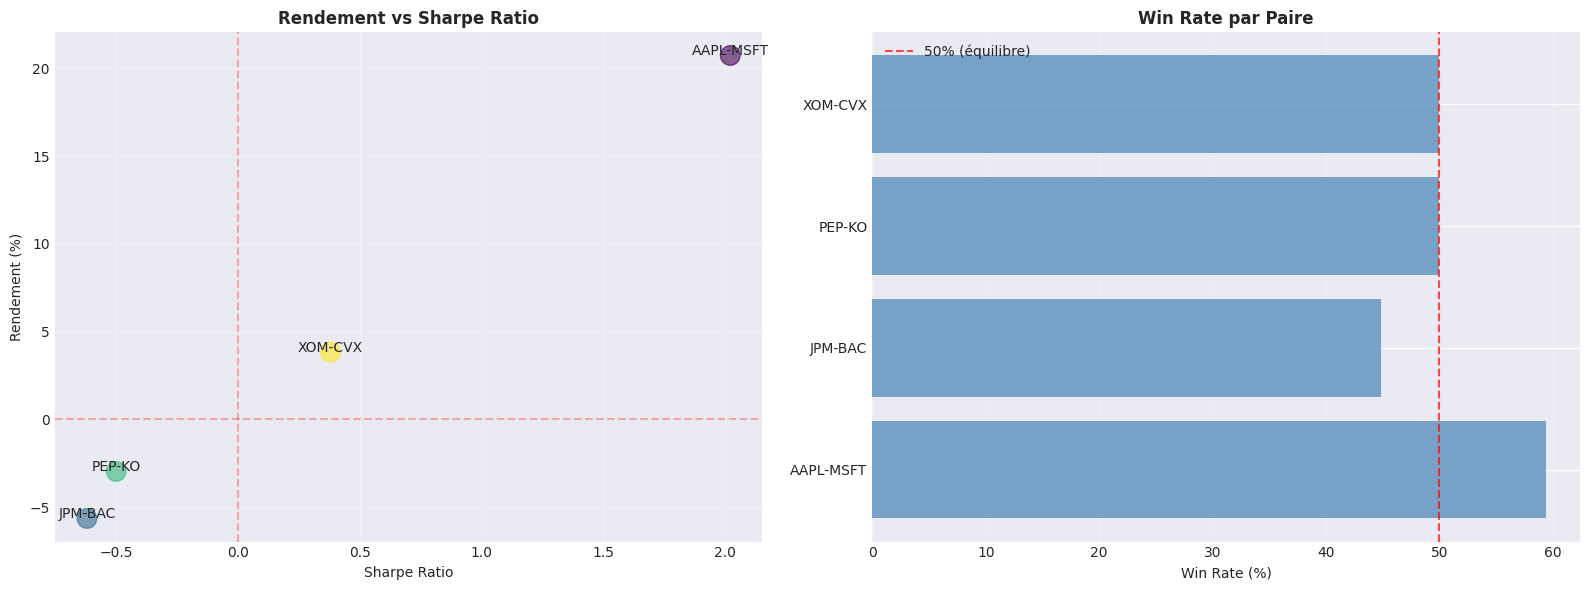

In [11]:
# Graphique comparatif des performances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Rendement vs Sharpe Ratio
axes[0].scatter(df_comparaison['Sharpe Ratio'], 
               df_comparaison['Rendement (%)'],
               s=200, alpha=0.6, c=range(len(df_comparaison)), cmap='viridis')

for idx, row in df_comparaison.iterrows():
    axes[0].annotate(row['Paire'], 
                    (row['Sharpe Ratio'], row['Rendement (%)']),
                    fontsize=10, ha='center')

axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('Rendement vs Sharpe Ratio', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sharpe Ratio')
axes[0].set_ylabel('Rendement (%)')
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Win Rate par paire
axes[1].barh(df_comparaison['Paire'], df_comparaison['Win Rate (%)'], color='steelblue', alpha=0.7)
axes[1].axvline(x=50, color='red', linestyle='--', label='50% (équilibre)', alpha=0.7)
axes[1].set_title('Win Rate par Paire', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Win Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. Conclusion

Ce notebook a démontré :

 **Configuration** du pipeline de trading  
 **Exécution** d'un backtest complet  
 **Visualisation** des résultats (prix, spread, z-score, equity curve)  
 **Comparaison** de plusieurs paires  
 **Identification** de la meilleure opportunité 